# Target Trial Emulation
The process begins by defining the estimand, such as intention-to-treat (ITT) or per-protocol (PP), and preparing observational data with specified columns for treatment, outcomes, and eligibility.

Censoring mechanisms, including treatment switching and informative censoring, are addressed using inverse probability of censoring weights (IPCW). Separate models are fitted to calculate these weights and adjust for biases.

The workflow proceeds to expand the observational dataset into a sequence of trials using pre-defined expansion options, creating trial-specific datasets. These datasets are then loaded and sampled for analysis.

A marginal structural model (MSM) is fit to estimate the causal effects. Predictions, such as survival probabilities and cumulative incidences, are generated for different treatment scenarios. The results are visualized to show survival differences over time, enabling meaningful inference on the treatment effects.

# 1. Setup

## Importing Necessary Libraries

In [1]:
import pandas as pd
import numpy as np
import os
import pickle
import tempfile
import matplotlib.pyplot as plt
import statsmodels.api as sm
import statsmodels.formula.api as smf

In [2]:
trial_pp_dir = os.path.join(tempfile.gettempdir(), "trial_pp")
os.makedirs(trial_pp_dir, exist_ok=True)

trial_itt_dir = os.path.join(tempfile.gettempdir(), "trial_itt")
os.makedirs(trial_itt_dir, exist_ok=True)


## Read CSV file

In [3]:
df = pd.read_csv("data_censored.csv")
df.head(40)

,id,period,treatment,x1,x2,x3,x4,age,age_s,outcome,censored,eligible
0,1,0,1,1,1.146148,0,0.734203,36,0.083333,0,0,1
1,1,1,1,1,0.002200,0,0.734203,37,0.166667,0,0,0
2,1,2,1,0,-0.481762,0,0.734203,38,0.250000,0,0,0
3,1,3,1,0,0.007872,0,0.734203,39,0.333333,0,0,0
4,1,4,1,1,0.216054,0,0.734203,40,0.416667,0,0,0
5,1,5,1,0,-0.057482,0,0.734203,41,0.500000,0,1,0
6,2,0,0,1,-0.802142,0,-0.990794,26,-0.750000,0,0,1
7,2,1,1,1,-0.983030,0,-0.990794,27,-0.666667,0,0,1
8,2,2,1,0,0.399388,0,-0.990794,28,-0.583333,0,0,0
9,2,3,0,0,1.835085,0,-0.990794,29,-0.500000,0,0,0


In [4]:
import os
import numpy as np
import pandas as pd
import statsmodels.api as sm
import statsmodels.formula.api as smf
import pickle

# A helper “save_to” function that simply marks that the expanded data will be kept as a DataFrame.
def save_to_datatable():
    # In this simple version, we simply return a marker (could be a dict or a string)
    return {"type": "datatable"}

# Extend the TrialSequence class with new methods
class TrialSequence:
    def __init__(self, estimand):
        self.estimand = estimand
        self.data = None
        self.id_col = None
        self.period_col = None
        self.treatment_col = None
        self.outcome_col = None
        self.eligible_col = None

        # Weight models (switch and censor)
        self.switch_weights = None
        self.censor_weights = None
        
        # New slots for outcome model and expansion
        self.outcome_model_settings = None   # Will be a dict storing model specs & fitted model
        self.expansion_options = None        # To store options like output type, chunk size, etc.
        self.expansion = None                # To store the expanded (trial sequence) data
        self.outcome_data = None             # Loaded outcome data (expanded and optionally sampled)
        self.msm_fit = None                  # The fitted marginal structural model
        
    def set_data(self, data, id_col, period_col, treatment_col, outcome_col, eligible_col):
        """
        Mimics the R set_data() function.
        """
        self.data = data.copy()  # assume data is a pandas DataFrame
        self.id_col = id_col
        self.period_col = period_col
        self.treatment_col = treatment_col
        self.outcome_col = outcome_col
        self.eligible_col = eligible_col
        return self

    def set_switch_weight_model(self, numerator, denominator, model_fitter, save_path=None):
        """
        Sets the switching weight model (for PP analyses).
        """
        self.switch_weights = {
            "numerator_formula": f"{self.treatment_col} ~ {numerator}",
            "denom_formula": f"{self.treatment_col} ~ {denominator}",
            "model_fitter": model_fitter,
            "save_path": save_path,
            "fitted_numerator": None,
            "fitted_denominator": None,
            "weights": None
        }
        return self

    def set_censor_weight_model(self, censor_event, numerator, denominator, pool_models, model_fitter, save_path=None):
        """
        Sets the censor weight model.
        """
        self.censor_weights = {
            "censor_event": censor_event,
            "numerator_formula": f"1 - {censor_event} ~ {numerator}",
            "denom_formula": f"1 - {censor_event} ~ {denominator}",
            "pool_models": pool_models,
            "model_fitter": model_fitter,
            "save_path": save_path,
            "fitted_numerator": None,
            "fitted_denominator": None,
            "weights": None
        }
        return self

    def calculate_weights(self):
        """
        Fits the logistic regression models for each weight model and computes stabilized weights.
        """
        # Calculate switch weights if specified
        if self.switch_weights is not None:
            sw = self.switch_weights
            num_save = os.path.join(sw["save_path"], "switch_numerator.pkl") if sw["save_path"] else None
            den_save = os.path.join(sw["save_path"], "switch_denom.pkl") if sw["save_path"] else None
            sw["fitted_numerator"] = sw["model_fitter"](sw["numerator_formula"], data=self.data, save_path=num_save)
            sw["fitted_denominator"] = sw["model_fitter"](sw["denom_formula"], data=self.data, save_path=den_save)
            self.data["switch_weight"] = sw["fitted_numerator"].predict(self.data) / sw["fitted_denominator"].predict(self.data)
            sw["weights"] = self.data["switch_weight"]

        # Calculate censor weights if specified
        if self.censor_weights is not None:
            cw = self.censor_weights
            num_save = os.path.join(cw["save_path"], "censor_numerator.pkl") if cw["save_path"] else None
            den_save = os.path.join(cw["save_path"], "censor_denom.pkl") if cw["save_path"] else None
            cw["fitted_numerator"] = cw["model_fitter"](cw["numerator_formula"], data=self.data, save_path=num_save)
            cw["fitted_denominator"] = cw["model_fitter"](cw["denom_formula"], data=self.data, save_path=den_save)
            self.data["censor_weight"] = cw["fitted_numerator"].predict(self.data) / cw["fitted_denominator"].predict(self.data)
            cw["weights"] = self.data["censor_weight"]
        return self

    def show_weight_models(self):
        """
        Prints a summary of the weight models stored in the object.
        """
        if self.switch_weights is not None:
            sw = self.switch_weights
            print("Switch Weights Model:")
            print("  Numerator formula:", sw["numerator_formula"])
            print("  Denominator formula:", sw["denom_formula"])
            print("  Model fitter type:", sw["model_fitter"].__name__)
            if sw["fitted_numerator"] is None:
                print("  Weight models not fitted. Use calculate_weights().")
            else:
                print("  Weights calculated.")
        if self.censor_weights is not None:
            cw = self.censor_weights
            print("Censor Weights Model:")
            print("  Numerator formula:", cw["numerator_formula"])
            print("  Denominator formula:", cw["denom_formula"])
            print("  Pooling:", cw["pool_models"])
            print("  Model fitter type:", cw["model_fitter"].__name__)
            if cw["fitted_numerator"] is None:
                print("  Weight models not fitted. Use calculate_weights().")
            else:
                print("  Weights calculated.")

    # ---------------------
    # New Methods for Outcome & Expansion
    # ---------------------
    def set_outcome_model(self, treatment_var=None, adjustment_terms="1", 
                          followup_time_terms="followup_time + I(followup_time**2)",
                          trial_period_terms="trial_period + I(trial_period**2)",
                          model_fitter=None):
        """
        Specify the outcome model.
        
        Parameters:
          treatment_var: For "As-Treated" analyses (e.g., dose). For ITT/PP, it might be fixed.
          adjustment_terms: A string representing additional covariates.
          followup_time_terms: A string to model followup time.
          trial_period_terms: A string to model trial start time.
          model_fitter: A function to fit the outcome model (e.g. a logistic regression fitter).
        """
        self.outcome_model_settings = {
            "treatment_var": treatment_var,
            "adjustment_terms": adjustment_terms,
            "followup_time_terms": followup_time_terms,
            "trial_period_terms": trial_period_terms,
            "model_fitter": model_fitter  # if None, we may default to our statsmodels fitter below
        }
        return self

    def set_expansion_options(self, output, chunk_size, first_period=0, last_period=np.inf):
        """
        Set options for expanding the observational data into a sequence of target trials.
        
        Parameters:
          output: an object created by save_to_datatable(), save_to_csv(), etc.
          chunk_size: number of patients to process at a time.
          first_period, last_period: range of periods to expand.
        """
        self.expansion_options = {
            "output": output,
            "chunk_size": chunk_size,
            "first_period": first_period,
            "last_period": last_period
        }
        return self

    def expand_trials(self):
        """
        Expand the person-time data to emulate a sequence of target trials.
        
        A very simplified implementation:
          For each patient, for each trial baseline between the patient’s min and max period,
          create a row with a follow-up time equal to (current period - trial baseline).
        """
        if self.data is None:
            raise ValueError("Data not set. Use set_data() first.")

        # For simplicity, assume self.data is in long format and contains a period column.
        expanded_rows = []
        for pid, group in self.data.groupby(self.id_col):
            min_period = group[self.period_col].min()
            max_period = group[self.period_col].max()
            # Use the provided expansion limits
            start = max(min_period, self.expansion_options.get("first_period", 0))
            end = min(max_period, self.expansion_options.get("last_period", max_period))
            # For each possible trial start period for this patient, create rows for followup
            for trial_start in range(int(start), int(end) + 1):
                # Get the subset of followup periods (rows) for this patient after trial_start
                followup = group[group[self.period_col] >= trial_start].copy()
                if followup.empty:
                    continue
                # Add/overwrite columns: trial_period and followup_time (time since trial start)
                followup["trial_period"] = trial_start
                followup["followup_time"] = followup[self.period_col] - trial_start
                expanded_rows.append(followup)
        if expanded_rows:
            self.expansion = pd.concat(expanded_rows, ignore_index=True)
        else:
            self.expansion = pd.DataFrame()
        return self

    def expansion_data(self):
        """
        Return the expanded trial data.
        """
        return self.expansion

    def load_expanded_data(self, p_control=None, subset_condition=None, seed=None):
        """
        Load (or subset) the expanded data.
        
        Optionally, sample controls (rows with outcome==0) with probability p_control.
        Optionally, subset rows based on a condition (a string that can be used with query()).
        """
        if self.expansion is None:
            raise ValueError("No expanded data found. Run expand_trials() first.")

        data_loaded = self.expansion.copy()

        if subset_condition is not None:
            data_loaded = data_loaded.query(subset_condition)

        if p_control is not None:
            # For outcome==0, sample with probability p_control
            np.random.seed(seed)
            is_control = data_loaded[self.outcome_col] == 0
            keep = np.ones(len(data_loaded), dtype=bool)
            # Randomly drop some control rows
            control_indices = data_loaded[is_control].index
            drop = np.random.rand(len(control_indices)) > p_control
            keep[control_indices] = ~drop
            data_loaded = data_loaded[keep]

        self.outcome_data = data_loaded
        return self

    def fit_msm(self, weight_cols=None, modify_weights=None):
        """
        Fit a marginal structural model (MSM) for the outcome.
        
        Parameters:
          weight_cols: list of column names in outcome_data to use for weights. The final weight
                       is taken as the product of these columns. If None, no weights are used.
          modify_weights: a function that takes a weight vector and returns modified weights (e.g., truncated).
        """
        if self.outcome_data is None:
            raise ValueError("Outcome data not loaded. Run load_expanded_data() first.")

        # Build the model formula. For simplicity, we assume:
        #   outcome ~ assigned_treatment + adjustment_terms + followup_time_terms + trial_period_terms
        # For ITT/PP, the treatment variable is automatically defined as "assigned_treatment".
        # (In a full implementation, you would construct the formula more carefully.)
        treatment_var = "assigned_treatment"
        adj = self.outcome_model_settings.get("adjustment_terms", "1")
        ft = self.outcome_model_settings.get("followup_time_terms", "followup_time + I(followup_time**2)")
        tp = self.outcome_model_settings.get("trial_period_terms", "trial_period + I(trial_period**2)")
        formula = f"{self.outcome_col} ~ {treatment_var} + {adj} + {ft} + {tp}"
        print("Fitting MSM with formula:", formula)
        
        # Compute final weights: if weight_cols is specified, multiply them.
        if weight_cols is not None:
            # Start with ones
            weights = np.ones(len(self.outcome_data))
            for col in weight_cols:
                weights *= self.outcome_data[col]
        else:
            weights = None

        if modify_weights is not None and weights is not None:
            weights = modify_weights(weights)

        # Use a default model fitter if not specified:
        def default_outcome_model_fitter(formula, data, weights=None, save_path=None):
            model = smf.glm(formula=formula, data=data, family=sm.families.Binomial(), weights=weights).fit()
            if save_path:
                with open(save_path, 'wb') as f:
                    pickle.dump(model, f)
            return model

        fitter = self.outcome_model_settings.get("model_fitter", default_outcome_model_fitter)
        fitted_model = fitter(formula, self.outcome_data, weights=weights)
        self.outcome_model_settings["fitted_model"] = fitted_model
        self.msm_fit = fitted_model
        return self

    def outcome_model(self):
        """
        Return the outcome model settings (including fitted model if available).
        """
        return self.outcome_model_settings

    def predict(self, newdata, predict_times, conf_int=True, samples=100, type="cum_inc"):
        if self.msm_fit is None:
            raise ValueError("MSM not fitted. Run fit_msm() first.")
        preds = []
        for t in predict_times:
            data_t = newdata.copy()
            data_t["followup_time"] = t
            # Get predictions for each row and then average them
            pred = self.msm_fit.predict(data_t)
            preds.append(np.mean(pred))
        result = pd.DataFrame({
            "followup_time": list(predict_times),
            "predicted": preds
        })
        # Dummy confidence intervals (for illustration)
        if conf_int:
            result["lower"] = result["predicted"] * 0.95
            result["upper"] = result["predicted"] * 1.05
        return result


# ---------------------
# Example model fitter functions using statsmodels for logistic regression.
def stats_glm_logit(formula, data, weights=None, save_path=None):
    model = smf.glm(formula=formula, data=data, family=sm.families.Binomial(), weights=weights).fit()
    if save_path:
        with open(save_path, 'wb') as f:
            pickle.dump(model, f)
    return model


In [5]:
def stats_glm_logit(formula, data, weights=None, robust=False, save_path=None):

    if weights is not None:
        # Use frequency weights if provided
        model = smf.glm(formula=formula, data=data, family=sm.families.Binomial(), freq_weights=weights)
    else:
        model = smf.glm(formula=formula, data=data, family=sm.families.Binomial())

    if robust:
        result = model.fit(cov_type='HC0')
    else:
        result = model.fit()
    return result

def te_stats_glm_logit(formula, data, treatment_col, treatment_val=1, control_val=0, save_path=None):
    # Fit the logistic regression model using statsmodels
    model = smf.glm(formula=formula, data=data, family=sm.families.Binomial()).fit()
    if save_path:
        with open(save_path, 'wb') as f:
            pickle.dump(model, f)
    return model

# 2. Data preparation


In [6]:
trial_pp = TrialSequence(estimand="PP")

trial_pp.set_data(
    data=df,
    id_col='id',
    period_col='period',
    treatment_col='treatment',
    outcome_col='outcome',
    eligible_col='eligible'
)

trial_itt = TrialSequence(estimand="ITT")

trial_itt.set_data(
    data=df,
    id_col='id',
    period_col='period',
    treatment_col='treatment',
    outcome_col='outcome',
    eligible_col='eligible'
)

In [7]:
trial_pp = TrialSequence(estimand="PP")

trial_pp.set_data(
    data=df,
    id_col='id',
    period_col='period',
    treatment_col='treatment',
    outcome_col='outcome',
    eligible_col='eligible'
)

trial_itt = TrialSequence(estimand="ITT")

trial_itt.set_data(
    data=df,
    id_col='id',
    period_col='period',
    treatment_col='treatment',
    outcome_col='outcome',
    eligible_col='eligible'
)

# 3. Weight models and censoring

## 3.1 Censoring due to treatment switching


In [8]:
trial_pp.set_switch_weight_model(
    numerator="age",  # use the column names as strings
    denominator="age + x1 + x3",
    model_fitter=stats_glm_logit,  # your logistic regression model fitting function
    save_path = trial_pp_dir
)

trial_pp.switch_weights

{'numerator_formula': 'treatment ~ age',
 'denom_formula': 'treatment ~ age + x1 + x3',
 'model_fitter': <function __main__.stats_glm_logit(formula, data, weights=None, robust=False, save_path=None)>,
 'save_path': 'C:\\Users\\USER\\AppData\\Local\\Temp\\trial_pp',
 'fitted_numerator': None,
 'fitted_denominator': None,
 'weights': None}

In [9]:
import os
from functools import partial
trial_pp.set_censor_weight_model(
    censor_event="censored",
    numerator="x2",         # Yields: 1 - censored ~ x2
    denominator="x2 + x1",    # Yields: 1 - censored ~ x2 + x1
    pool_models="none",
    model_fitter=lambda formula, data, save_path=None: te_stats_glm_logit(
        formula, data, treatment_col="treatment", save_path=save_path
    ),
    save_path=trial_pp_dir
)

trial_pp.censor_weights

{'censor_event': 'censored',
 'numerator_formula': '1 - censored ~ x2',
 'denom_formula': '1 - censored ~ x2 + x1',
 'pool_models': 'none',
 'model_fitter': <function __main__.<lambda>(formula, data, save_path=None)>,
 'save_path': 'C:\\Users\\USER\\AppData\\Local\\Temp\\trial_pp',
 'fitted_numerator': None,
 'fitted_denominator': None,
 'weights': None}

In [10]:
trial_itt.set_censor_weight_model(
    censor_event="censored",
    numerator="x2",         # This will yield: 1 - censored ~ x2
    denominator="x2 + x1",  # This will yield: 1 - censored ~ x2 + x1
    pool_models="numerator",
    model_fitter=stats_glm_logit,  # your logistic regression model fitting function
    save_path=trial_itt_dir
)

trial_itt.censor_weights

{'censor_event': 'censored',
 'numerator_formula': '1 - censored ~ x2',
 'denom_formula': '1 - censored ~ x2 + x1',
 'pool_models': 'numerator',
 'model_fitter': <function __main__.stats_glm_logit(formula, data, weights=None, robust=False, save_path=None)>,
 'save_path': 'C:\\Users\\USER\\AppData\\Local\\Temp\\trial_itt',
 'fitted_numerator': None,
 'fitted_denominator': None,
 'weights': None}

# 4. Calculate weights

In [11]:
trial_pp.calculate_weights()
trial_itt.calculate_weights()

d:\Anaconda\envs\data_ana\lib\site-packages\statsmodels\genmod\generalized_linear_model.py:1342: PerfectSeparationWarning: Perfect separation or prediction detected, parameter may not be identified
  warnings.warn(msg, category=PerfectSeparationWarning)
d:\Anaconda\envs\data_ana\lib\site-packages\statsmodels\genmod\generalized_linear_model.py:1342: PerfectSeparationWarning: Perfect separation or prediction detected, parameter may not be identified
  warnings.warn(msg, category=PerfectSeparationWarning)
d:\Anaconda\envs\data_ana\lib\site-packages\statsmodels\genmod\generalized_linear_model.py:1342: PerfectSeparationWarning: Perfect separation or prediction detected, parameter may not be identified
  warnings.warn(msg, category=PerfectSeparationWarning)
d:\Anaconda\envs\data_ana\lib\site-packages\statsmodels\genmod\generalized_linear_model.py:1342: PerfectSeparationWarning: Perfect separation or prediction detected, parameter may not be identified
  warnings.warn(msg, category=PerfectSep

In [12]:
trial_itt.show_weight_models()

Censor Weights Model:
  Numerator formula: 1 - censored ~ x2
  Denominator formula: 1 - censored ~ x2 + x1
  Pooling: numerator
  Model fitter type: stats_glm_logit
  Weights calculated.


In [13]:
print(trial_itt.censor_weights["weights"])


0      1.0
1      1.0
2      1.0
3      1.0
4      1.0
      ... 
720    1.0
721    1.0
722    1.0
723    1.0
724    1.0
Name: censor_weight, Length: 725, dtype: float64


In [14]:
trial_itt.__dict__

{'estimand': 'ITT',
 'data':      id  period  treatment  x1        x2  x3        x4  age     age_s  \
 0     1       0          1   1  1.146148   0  0.734203   36  0.083333   
 1     1       1          1   1  0.002200   0  0.734203   37  0.166667   
 2     1       2          1   0 -0.481762   0  0.734203   38  0.250000   
 3     1       3          1   0  0.007872   0  0.734203   39  0.333333   
 4     1       4          1   1  0.216054   0  0.734203   40  0.416667   
 ..   ..     ...        ...  ..       ...  ..       ...  ...       ...   
 720  99       3          0   0 -0.747906   1  0.575268   68  2.750000   
 721  99       4          0   0 -0.790056   1  0.575268   69  2.833333   
 722  99       5          1   1  0.387429   1  0.575268   70  2.916667   
 723  99       6          1   1 -0.033762   1  0.575268   71  3.000000   
 724  99       7          0   0 -1.340497   1  0.575268   72  3.083333   
 
      outcome  censored  eligible  censor_weight  
 0          0         0        

In [15]:
trial_pp.__dict__

{'estimand': 'PP',
 'data':      id  period  treatment  x1        x2  x3        x4  age     age_s  \
 0     1       0          1   1  1.146148   0  0.734203   36  0.083333   
 1     1       1          1   1  0.002200   0  0.734203   37  0.166667   
 2     1       2          1   0 -0.481762   0  0.734203   38  0.250000   
 3     1       3          1   0  0.007872   0  0.734203   39  0.333333   
 4     1       4          1   1  0.216054   0  0.734203   40  0.416667   
 ..   ..     ...        ...  ..       ...  ..       ...  ...       ...   
 720  99       3          0   0 -0.747906   1  0.575268   68  2.750000   
 721  99       4          0   0 -0.790056   1  0.575268   69  2.833333   
 722  99       5          1   1  0.387429   1  0.575268   70  2.916667   
 723  99       6          1   1 -0.033762   1  0.575268   71  3.000000   
 724  99       7          0   0 -1.340497   1  0.575268   72  3.083333   
 
      outcome  censored  eligible  switch_weight  censor_weight  
 0          0    

# 5. Specify Outcome Model


In [16]:
trial_pp.set_outcome_model(model_fitter=stats_glm_logit)
trial_itt.set_outcome_model(adjustment_terms="x2", model_fitter=stats_glm_logit)

# 6. Expand Trials


In [17]:
# Set expansion options.
trial_pp.set_expansion_options(output=save_to_datatable(), chunk_size=500)
trial_itt.set_expansion_options(output=save_to_datatable(), chunk_size=500)


## 6.1 Create Sequence of Trials Data

In [18]:
# Expand trials.
trial_pp.expand_trials()
trial_itt.expand_trials()

In [19]:
print("Expanded data (trial_pp):")
print(trial_pp.expansion_data().head())

Expanded data (trial_pp):
   id  period  treatment  x1        x2  x3        x4  age     age_s  outcome  \
0   1       0          1   1  1.146148   0  0.734203   36  0.083333        0   
1   1       1          1   1  0.002200   0  0.734203   37  0.166667        0   
2   1       2          1   0 -0.481762   0  0.734203   38  0.250000        0   
3   1       3          1   0  0.007872   0  0.734203   39  0.333333        0   
4   1       4          1   1  0.216054   0  0.734203   40  0.416667        0   

   censored  eligible  switch_weight  censor_weight  trial_period  \
0         0         1       0.930088            1.0             0   
1         0         0       0.928634            1.0             0   
2         0         0       1.039459            1.0             0   
3         0         0       1.040816            1.0             0   
4         0         0       0.924292            1.0             0   

   followup_time  
0              0  
1              1  
2              2  
3 

# 7. Load or Sample from Expanded Data

In [20]:
trial_itt.load_expanded_data(seed=1234, p_control=0.5)
trial_itt.outcome_data["assigned_treatment"] = trial_itt.outcome_data[trial_itt.treatment_col]


In [21]:
if "weight" not in trial_itt.outcome_data.columns:
    trial_itt.outcome_data["weight"] = 1.0
if "sample_weight" not in trial_itt.outcome_data.columns:
    trial_itt.outcome_data["sample_weight"] = 1.0

# 8. Fit Marginal Structural Model

In [22]:
trial_itt.fit_msm(
    weight_cols=["weight", "sample_weight"],
    modify_weights=lambda w: np.minimum(w, np.quantile(w, 0.99))  # winsorize extreme weights
)


Fitting MSM with formula: outcome ~ assigned_treatment + x2 + followup_time + I(followup_time**2) + trial_period + I(trial_period**2)


In [23]:
print("\nOutcome model settings (trial_itt):")
print(trial_itt.outcome_model())
print("\nUnderlying GLM model:")
print(trial_itt.outcome_model_settings["fitted_model"].model)


Outcome model settings (trial_itt):
{'treatment_var': None, 'adjustment_terms': 'x2', 'followup_time_terms': 'followup_time + I(followup_time**2)', 'trial_period_terms': 'trial_period + I(trial_period**2)', 'model_fitter': <function stats_glm_logit at 0x0000027CE7533670>, 'fitted_model': <statsmodels.genmod.generalized_linear_model.GLMResultsWrapper object at 0x0000027CE96E8490>}

Underlying GLM model:


In [24]:
baseline = trial_itt.outcome_data[trial_itt.outcome_data["trial_period"] == 1]
preds = trial_itt.predict(newdata=baseline, predict_times=range(0, 11), type="survival")
print("\nPredictions:")
print(preds)


Predictions:
    followup_time  predicted     lower     upper
0               0   0.043875  0.041681  0.046068
1               1   0.044568  0.042339  0.046796
2               2   0.044488  0.042263  0.046712
3               3   0.043639  0.041457  0.045821
4               4   0.042062  0.039958  0.044165
5               5   0.039832  0.037840  0.041823
6               6   0.037053  0.035201  0.038906
7               7   0.033853  0.032161  0.035546
8               8   0.030371  0.028852  0.031889
9               9   0.026748  0.025411  0.028085
10             10   0.023122  0.021966  0.024278


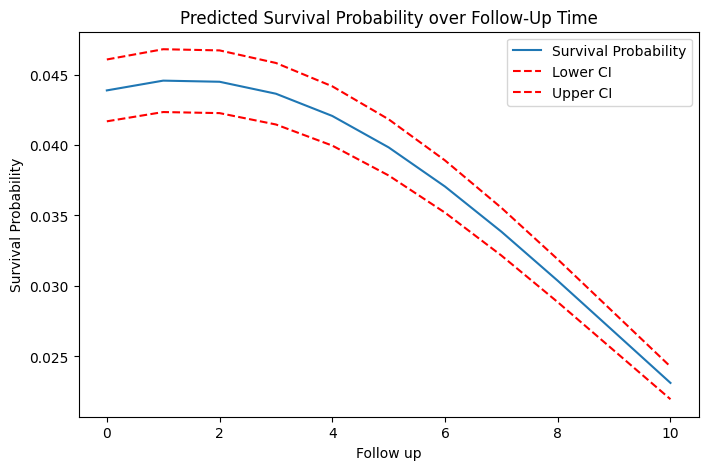

In [25]:
plt.figure(figsize=(8, 5))
plt.plot(preds["followup_time"], preds["predicted"], label="Survival Probability", linestyle="solid")
plt.plot(preds["followup_time"], preds["lower"], label="Lower CI", linestyle="dashed", color="red")
plt.plot(preds["followup_time"], preds["upper"], label="Upper CI", linestyle="dashed", color="red")
plt.xlabel("Follow up")
plt.ylabel("Survival Probability")
plt.title("Predicted Survival Probability over Follow-Up Time")
plt.legend()
plt.show()